# Notebook 04 — Correlation & Root Cause Analysis
**Project:** CompSpirit — Huawei Telecom Complaint Analytics & Network Intelligence Platform
**Deliverable:** D3 Part 2 — KPI–Complaint Correlation & Root Cause Detection

**Inputs (from Notebook 02):**
- `data/processed/complaint_daily_agg.parquet`
- `data/processed/kpi_daily_agg.parquet`
- `data/processed/feature_matrix.parquet`

**Outputs:**
- `reports/figures/d3_*.png`  — 9 charts
- `reports/exports/d3_*.csv` — 5 analysis tables

**Table of Contents**
1. Setup & Load
2. Pearson & Spearman Correlations
3. KPI Threshold Detection
4. Granger Causality
5. QoE Degradation Events
6. Cross-Correlation (CCF)
7. D3 Deliverable Summary & Checklist

## Cell 0 — Environment setup
FIX N1: portable project-root detection; FIX N5: scoped warnings; FIX N7: FIGURES defined here.

In [25]:
import sys
from pathlib import Path

def _find_project_root(start: Path, marker: str = "config") -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).is_dir():
            return parent
    raise RuntimeError(
        f"Cannot locate project root (looking for '{marker}/' directory)."
    )

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import os
os.chdir(PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr   # single import — no duplicate in later cells (FIX N2)

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="darkgrid")
COLORS  = sns.color_palette("husl", 10)
FIGURES = "reports/figures"
os.makedirs(FIGURES, exist_ok=True)
os.makedirs("reports/exports", exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"pandas       : {pd.__version__}")
print("Environment ready ✓")

Project root : C:\Users\c50057188\Desktop\PFE_Ouerghi
pandas       : 2.3.3
Environment ready ✓


## Cell 1 — Load processed datasets

In [26]:
complaint_agg  = pd.read_parquet("data/processed/complaint_daily_agg.parquet")
kpi_agg        = pd.read_parquet("data/processed/kpi_daily_agg.parquet")
feature_matrix = pd.read_parquet("data/processed/feature_matrix.parquet")

complaint_agg["date"] = pd.to_datetime(complaint_agg["date"])
kpi_agg["date"]       = pd.to_datetime(kpi_agg["date"])

print(f"complaint_agg  : {complaint_agg.shape}")
print(f"kpi_agg        : {kpi_agg.shape}")
print(f"feature_matrix : {feature_matrix.shape}  nulls={feature_matrix.isnull().sum().sum()}")

complaint_agg  : (8088, 21)
kpi_agg        : (8088, 108)
feature_matrix : (8088, 145)  nulls=0


## Cell 2 — Run full correlation & root cause analysis module

In [27]:
from src.analysis.correlation import CorrelationAnalyser

corr    = CorrelationAnalyser()
results = corr.run(complaint_agg, kpi_agg, feature_matrix)

# Unpack for convenience
top_corr   = results["top_correlations"]
thresholds = results["thresholds"]
granger    = results["granger_results"]
qoe_events = results["qoe_event_analysis"]
ccf        = results["ccf_results"]
joined     = results["joined"]
summary    = results["summary"]

2026-05-06 01:35:49.488 | INFO     | src.analysis.correlation:run:121 - ============================================================
2026-05-06 01:35:49.494 | INFO     | src.analysis.correlation:run:122 - CORRELATION & ROOT CAUSE ANALYSIS  (D3)
2026-05-06 01:35:49.498 | INFO     | src.analysis.correlation:run:123 - ============================================================
2026-05-06 01:35:49.501 | INFO     | src.analysis.correlation:run:125 - 
[0/5] Joining complaint + KPI aggregates ...
2026-05-06 01:35:49.640 | INFO     | src.analysis.correlation:run:127 -   Joined dataset: 8,088 rows
2026-05-06 01:35:49.649 | INFO     | src.analysis.correlation:run:129 - 
[1/5] Computing Pearson & Spearman correlation matrices ...
2026-05-06 01:35:49.882 | INFO     | src.analysis.correlation:_correlation_matrices:286 -   Top 5 KPIs correlated with total_complaints (Pearson):
2026-05-06 01:35:49.886 | INFO     | src.analysis.correlation:_correlation_matrices:288 -     Call Drop Rate (%)           

## Cell 3 — Correlation rankings table

In [28]:
print("=== KPI → Total Complaints Correlation Rankings ===")
if top_corr.empty:
    print("No KPI mean columns found — run with synthetic KPI data or wait for real KPI exports.")
else:
    display(  # type: ignore[name-defined]
        top_corr[[
            "kpi_label", "pearson_r", "pearson_p", "pearson_sig",
            "spearman_r", "spearman_p", "spearman_sig",
        ]]
    )

=== KPI → Total Complaints Correlation Rankings ===


,kpi_label,pearson_r,pearson_p,pearson_sig,spearman_r,spearman_p,spearman_sig
0,Call Drop Rate (%),0.4570,0.0,✓,0.6040,0.0,✓
1,Latency (ms),0.4567,0.0,✓,0.6078,0.0,✓
2,Packet Loss (%),0.4485,0.0,✓,0.5857,0.0,✓
3,Call Setup SR (%),0.3960,0.0,✓,0.2941,0.0,✓
4,Data Session SR (%),0.3959,0.0,✓,0.3029,0.0,✓
5,Handover SR (%),0.3958,0.0,✓,0.2849,0.0,✓
6,qoe_score_mean,0.3941,0.0,✓,0.3501,0.0,✓
7,Voice MOS,0.3937,0.0,✓,0.3595,0.0,✓
8,Data QoE Score,0.3933,0.0,✓,0.3934,0.0,✓
9,Voice QoE Score,0.3929,0.0,✓,0.3642,0.0,✓


## Cell 4 — Pearson r bar chart

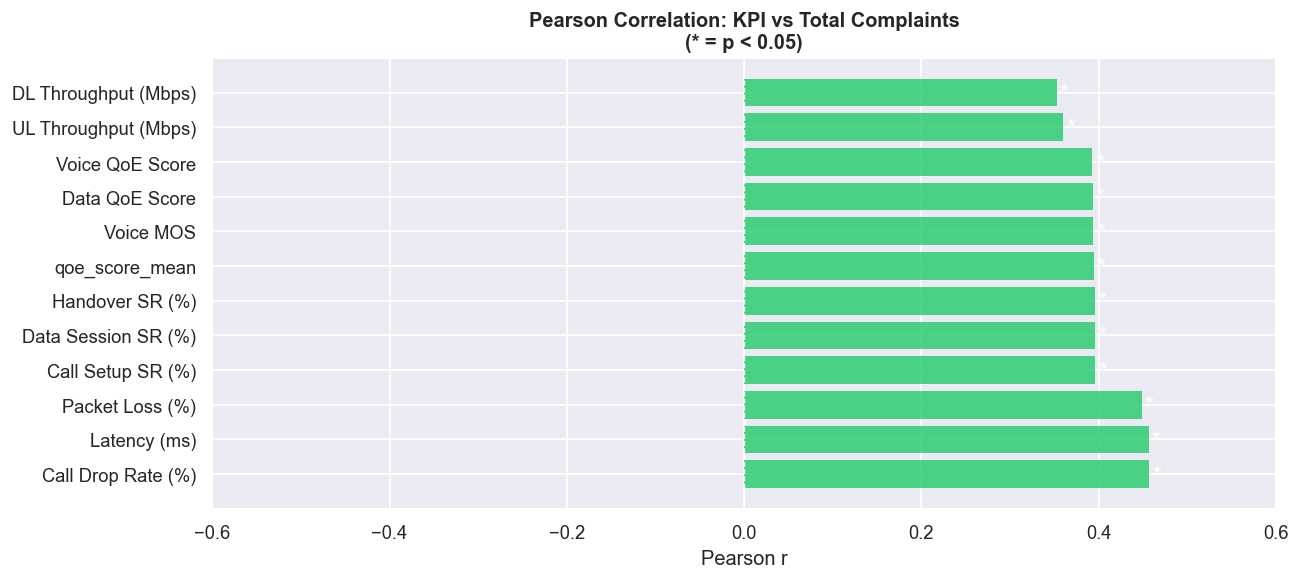

In [29]:
if not top_corr.empty:
    fig, ax = plt.subplots(figsize=(11, 5))
    colors  = ["#e74c3c" if r < 0 else "#2ecc71" for r in top_corr["pearson_r"]]
    ax.barh(top_corr["kpi_label"], top_corr["pearson_r"],
            color=colors, edgecolor="none", alpha=0.85)
    ax.axvline(0, color="white", linewidth=0.8, linestyle="--")

    for i, (r, sig) in enumerate(zip(top_corr["pearson_r"], top_corr["pearson_sig"])):
        if sig == "✓":
            ax.text(
                r + (0.003 if r >= 0 else -0.003), i, "*",
                va="center", ha="left" if r >= 0 else "right",
                fontsize=14, color="white",
            )

    ax.set_title("Pearson Correlation: KPI vs Total Complaints\n(* = p < 0.05)",
                 fontweight="bold")
    ax.set_xlabel("Pearson r")
    ax.set_xlim(-0.6, 0.6)
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d3_pearson_correlation_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No correlations to plot.")

## Cell 5 — Full Pearson correlation heatmap

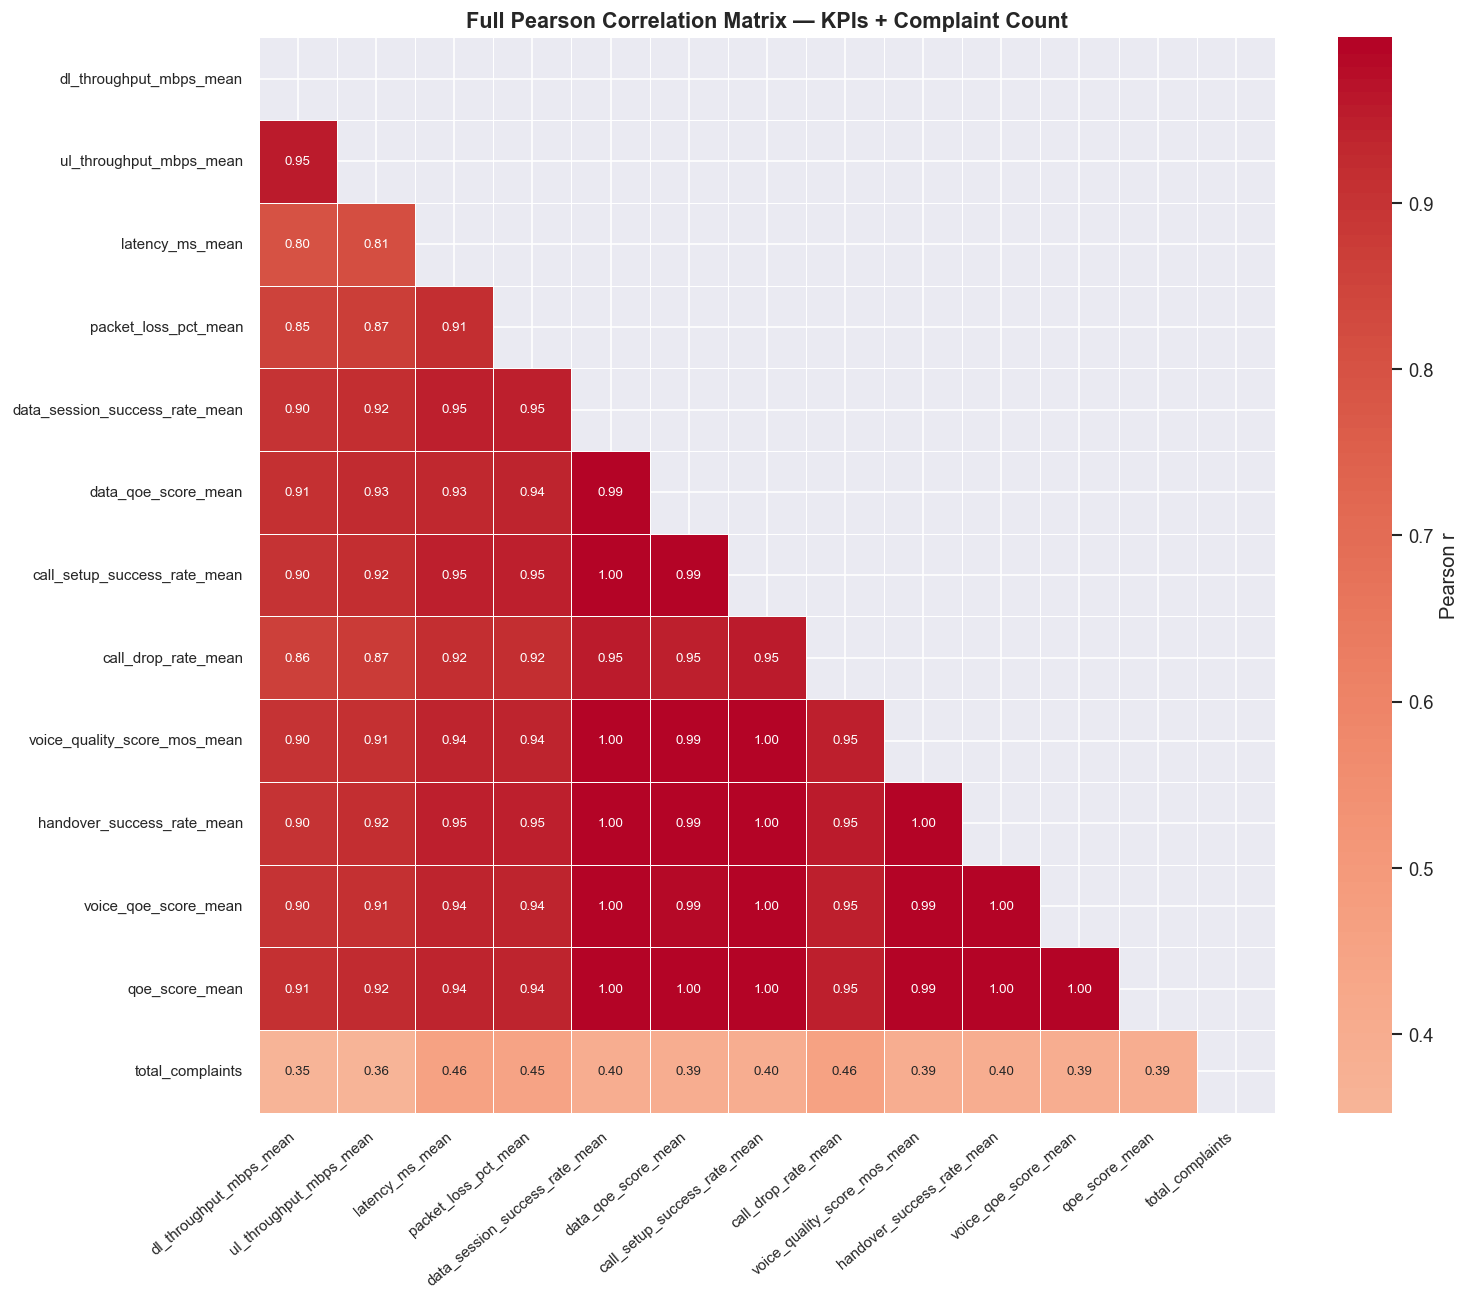

In [30]:
pearson_mat = results["pearson_matrix"]

if not pearson_mat.empty and pearson_mat.shape[0] > 1:
    fig, ax = plt.subplots(figsize=(13, 11))
    mask = np.triu(np.ones_like(pearson_mat, dtype=bool))
    sns.heatmap(
        pearson_mat, mask=mask, annot=True, fmt=".2f",
        cmap="coolwarm", center=0, linewidths=0.4,
        annot_kws={"size": 8}, ax=ax,
        cbar_kws={"label": "Pearson r"},
    )
    ax.set_title("Full Pearson Correlation Matrix — KPIs + Complaint Count",
                 fontsize=13, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d3_full_correlation_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Correlation matrix empty — no numeric KPI columns in joined dataset.")

## Cell 6 — Scatter plots: top 4 correlated KPIs vs complaints

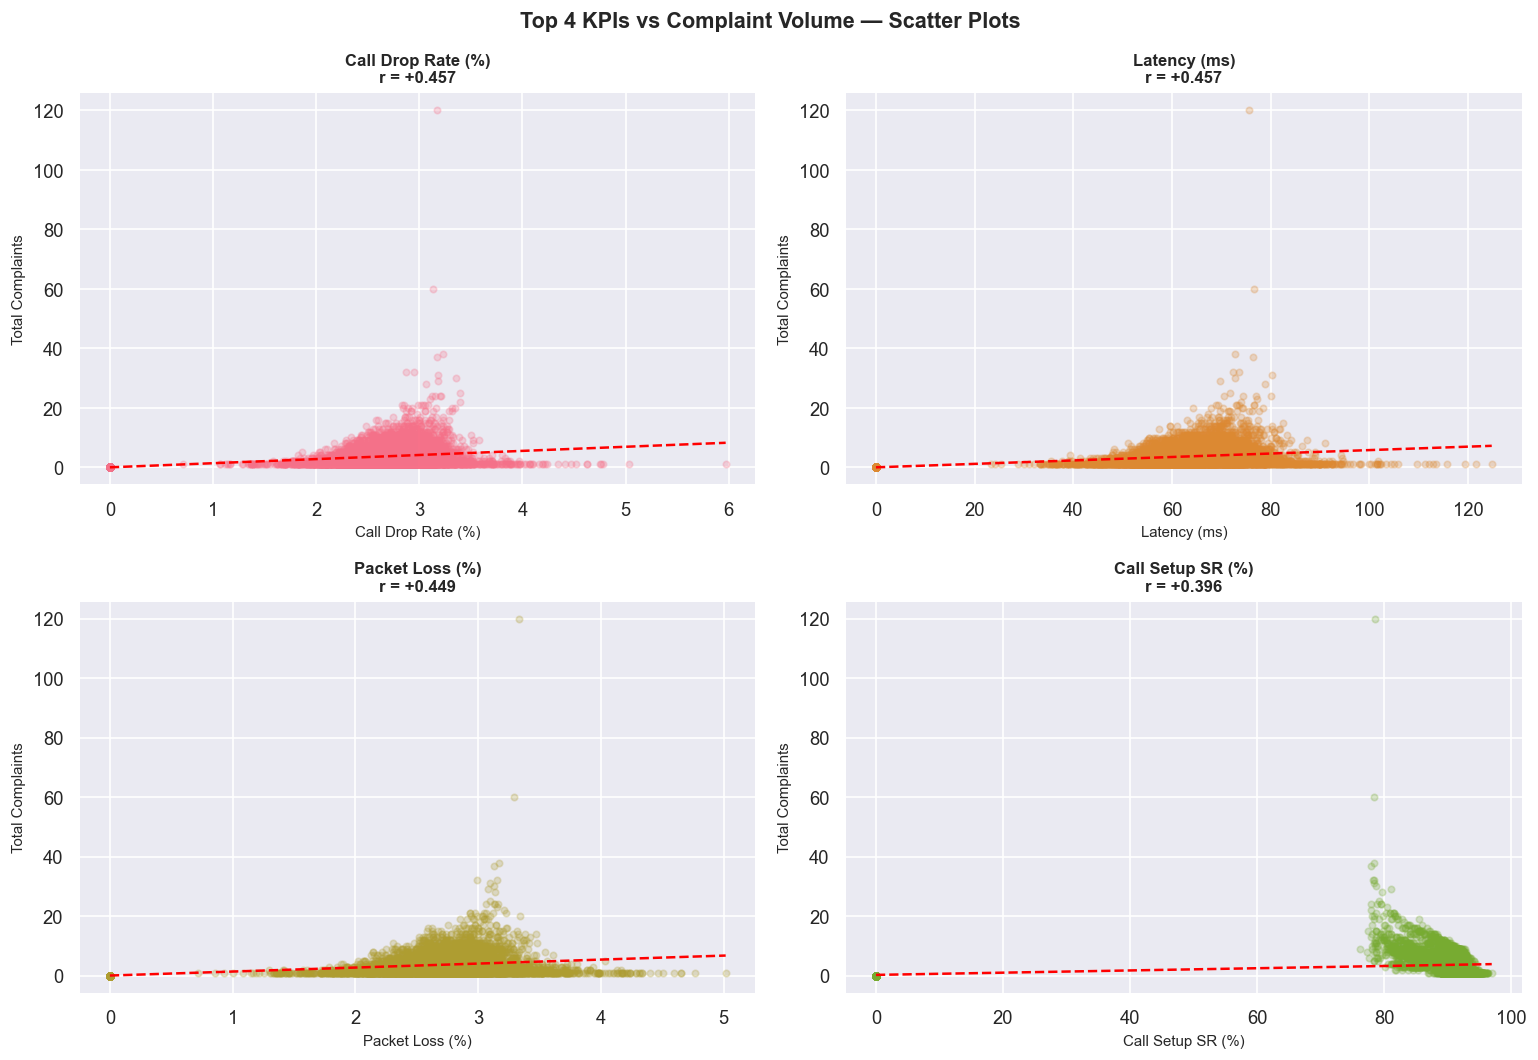

In [31]:
if not top_corr.empty:
    top4_kpi = top_corr["kpi"].head(4).tolist()
    top4_lbl = top_corr["kpi_label"].head(4).tolist()

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()

    for i, (kpi, label) in enumerate(zip(top4_kpi, top4_lbl)):
        if kpi not in joined.columns:
            axes[i].text(0.5, 0.5, f"{label}\nnot in joined dataset",
                         ha="center", va="center", transform=axes[i].transAxes)
            continue
        pair = joined[[kpi, "total_complaints"]].dropna()
        r    = top_corr.loc[top_corr["kpi"] == kpi, "pearson_r"].values[0]

        axes[i].scatter(pair[kpi], pair["total_complaints"],
                        alpha=0.25, s=15, color=COLORS[i])
        z      = np.polyfit(pair[kpi], pair["total_complaints"], 1)
        x_line = np.linspace(pair[kpi].min(), pair[kpi].max(), 100)
        axes[i].plot(x_line, np.poly1d(z)(x_line),
                     color="red", linewidth=1.5, linestyle="--")
        axes[i].set_title(f"{label}\nr = {r:+.3f}", fontweight="bold", fontsize=10)
        axes[i].set_xlabel(label, fontsize=9)
        axes[i].set_ylabel("Total Complaints", fontsize=9)

    plt.suptitle("Top 4 KPIs vs Complaint Volume — Scatter Plots",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d3_kpi_complaint_scatterplots.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No KPI correlations available for scatter plots.")

## Cell 7 — KPI threshold table

In [32]:
print("=== KPI Complaint-Spike Thresholds ===")
if thresholds.empty:
    print("No thresholds computed — insufficient spike days or no KPI mean columns.")
else:
    display(  # type: ignore[name-defined]
        thresholds[[
            "kpi_label", "threshold_value", "direction",
            "spike_rate_below", "spike_rate_above", "gini_improvement",
        ]]
    )

=== KPI Complaint-Spike Thresholds ===


,kpi_label,threshold_value,direction,spike_rate_below,spike_rate_above,gini_improvement
0,Call Setup SR (%),85.863,below,0.129,0.001,0.00673
1,Handover SR (%),87.437,below,0.126,0.000,0.00667
2,Data Session SR (%),84.222,below,0.126,0.001,0.00650
3,Call Drop Rate (%),2.909,above,0.010,0.140,0.00567
4,Packet Loss (%),2.900,above,0.009,0.128,0.00513
5,qoe_score_mean,64.955,below,0.113,0.004,0.00499
6,Latency (ms),71.654,above,0.017,0.158,0.00493
7,Voice MOS,3.237,below,0.112,0.005,0.00484
8,Voice QoE Score,66.588,below,0.107,0.005,0.00451
9,Data QoE Score,63.606,below,0.096,0.006,0.00374


## Cell 8 — Spike rate below vs above threshold (grouped bar)

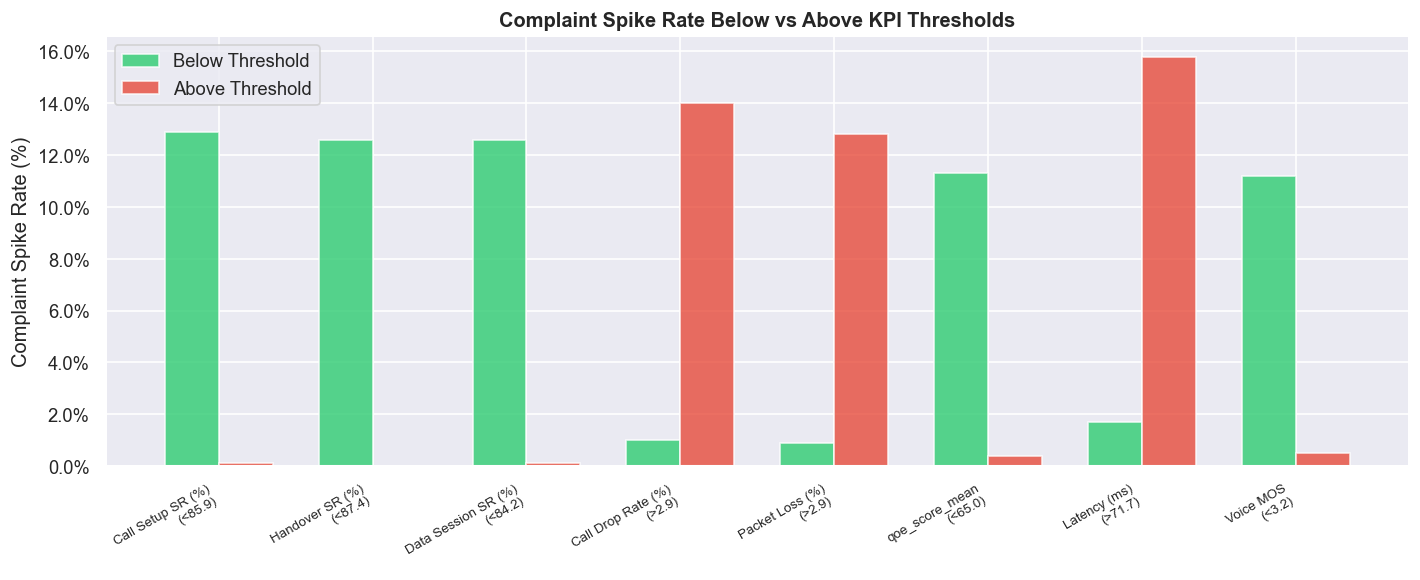

In [33]:
if not thresholds.empty:
    thresh_top = thresholds.head(8).copy()
    fig, ax    = plt.subplots(figsize=(12, 5))
    x     = np.arange(len(thresh_top))
    width = 0.35

    ax.bar(x - width / 2, thresh_top["spike_rate_below"] * 100,
           width, label="Below Threshold", color="#2ecc71", alpha=0.8)
    ax.bar(x + width / 2, thresh_top["spike_rate_above"] * 100,
           width, label="Above Threshold", color="#e74c3c", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            (f"{row['kpi_label']}\n(>{row['threshold_value']:.1f})"
             if row["direction"] == "above"
             else f"{row['kpi_label']}\n(<{row['threshold_value']:.1f})")
            for _, row in thresh_top.iterrows()
        ],
        rotation=30, ha="right", fontsize=8,
    )
    ax.set_ylabel("Complaint Spike Rate (%)")
    ax.set_title("Complaint Spike Rate Below vs Above KPI Thresholds", fontweight="bold")
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d3_kpi_thresholds.png", dpi=150, bbox_inches="tight")
    plt.show()

## Cell 9 — Threshold detail: top KPI
FIX N6: explicit message when guard condition is not met.

C:\Users\c50057188\AppData\Local\Temp\ipykernel_10264\3199237585.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


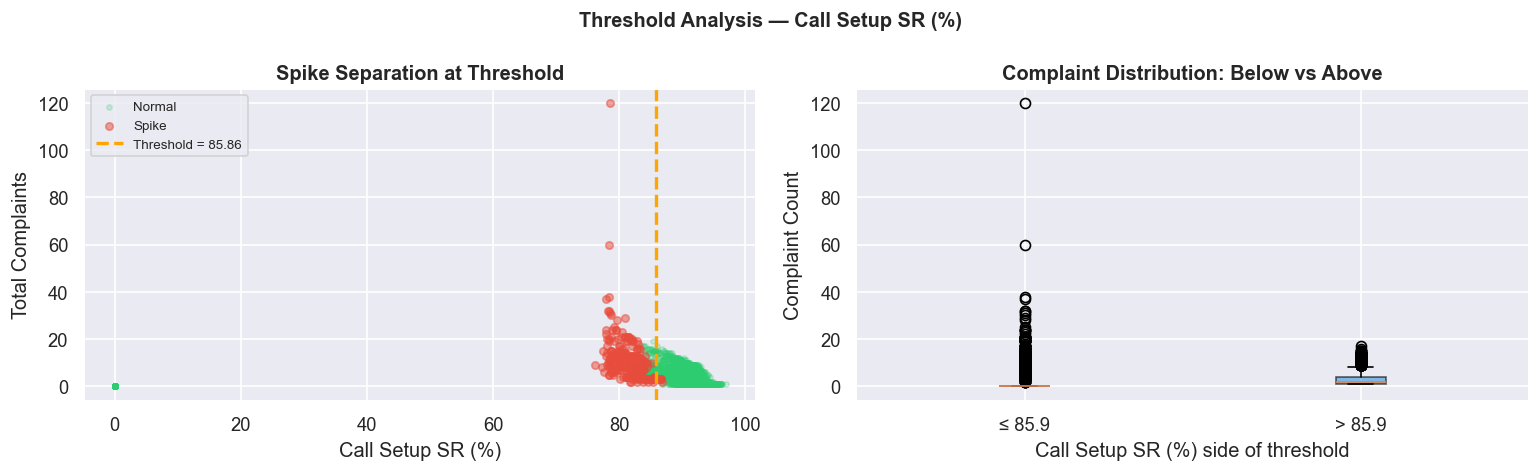

In [34]:
if not thresholds.empty:
    best_kpi    = thresholds.iloc[0]["kpi"]
    best_label  = thresholds.iloc[0]["kpi_label"]
    best_thresh = thresholds.iloc[0]["threshold_value"]

    if best_kpi not in joined.columns:
        print(f"  Column '{best_kpi}' not in joined dataset — threshold detail skipped.")
    elif "complaint_spike_flag" not in joined.columns:
        print("  complaint_spike_flag absent — threshold scatter skipped.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        normal_pts = joined[joined["complaint_spike_flag"] == 0]
        spike_pts  = joined[joined["complaint_spike_flag"] == 1]
        axes[0].scatter(normal_pts[best_kpi], normal_pts["total_complaints"],
                        alpha=0.2, s=10, color="#2ecc71", label="Normal")
        axes[0].scatter(spike_pts[best_kpi], spike_pts["total_complaints"],
                        alpha=0.5, s=20, color="#e74c3c", label="Spike")
        axes[0].axvline(best_thresh, color="orange", linewidth=2,
                        linestyle="--", label=f"Threshold = {best_thresh:.2f}")
        axes[0].set_xlabel(best_label)
        axes[0].set_ylabel("Total Complaints")
        axes[0].set_title("Spike Separation at Threshold", fontweight="bold")
        axes[0].legend(fontsize=8)

        below_data = joined[joined[best_kpi] <= best_thresh]["total_complaints"]
        above_data = joined[joined[best_kpi] >  best_thresh]["total_complaints"]
        axes[1].boxplot(
            [below_data.dropna(), above_data.dropna()],
            labels=[f"≤ {best_thresh:.1f}", f"> {best_thresh:.1f}"],
            patch_artist=True,
            boxprops=dict(facecolor="#3498db", alpha=0.6),
        )
        axes[1].set_xlabel(f"{best_label} side of threshold")
        axes[1].set_ylabel("Complaint Count")
        axes[1].set_title("Complaint Distribution: Below vs Above", fontweight="bold")

        plt.suptitle(f"Threshold Analysis — {best_label}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"{FIGURES}/d3_threshold_detail.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("No thresholds available — threshold detail skipped.")

## Cell 10 — Granger causality table

In [35]:
if granger.empty:
    print("Granger results empty — statsmodels may not be installed.")
    print("Install with: pip install statsmodels")
else:
    n_sig = granger["is_significant"].sum()
    print(f"Total tests   : {len(granger)}")
    print(f"Significant (p < 0.05): {n_sig}")
    print()
    if n_sig > 0:
        display(  # type: ignore[name-defined]
            granger[granger["is_significant"]][[
                "region", "kpi_label", "best_lag_days",
                "min_p_value", "interpretation",
            ]].head(15)
        )
    else:
        print("No significant Granger causal links found in current data.")
        print("(Expected with synthetic KPI — real operator data will show stronger signals.)")

Total tests   : 144
Significant (p < 0.05): 21



,region,kpi_label,best_lag_days,min_p_value,interpretation
0,Sousse Gouvernorat,Data Session SR (%),1,0.00028,Data Session Success Rate Granger-causes compl...
1,Sousse Gouvernorat,Data QoE Score,1,0.00050,Data Qoe Score Granger-causes complaints with ...
2,Sousse Gouvernorat,Packet Loss (%),1,0.00062,Packet Loss Pct Granger-causes complaints with...
3,Sousse Gouvernorat,DL Throughput (Mbps),1,0.00109,Dl Throughput Mbps Granger-causes complaints w...
4,Sousse Gouvernorat,Latency (ms),1,0.00166,Latency Ms Granger-causes complaints with 1-da...
5,Sousse Gouvernorat,UL Throughput (Mbps),1,0.00266,Ul Throughput Mbps Granger-causes complaints w...
6,Béja Gouvernorat,Packet Loss (%),6,0.00750,Packet Loss Pct Granger-causes complaints with...
7,Mahdia Gouvernorat,Data QoE Score,1,0.00959,Data Qoe Score Granger-causes complaints with ...
8,Mahdia Gouvernorat,Data Session SR (%),1,0.01397,Data Session Success Rate Granger-causes compl...
9,Nabeul Gouvernorat,Packet Loss (%),3,0.01784,Packet Loss Pct Granger-causes complaints with...


## Cell 11 — Granger heatmap (lag × KPI)

c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\c50057188\AppData\Local\Temp\ipykernel_10264\4083363120.py:19: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\c50057188\AppData\Local\Temp\ipykernel_10264\4083363120.py:19: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\c50057188\AppData\Local\Temp\ipykernel_10264\4083363120.py:20: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(f"{FIGURES}/d3_granger_heatmap.png", dpi=150, bbox_inches="tight")
C:\Users\c50057188\AppData\Local\Temp\ipykernel_10264\4083363120.py:20: UserWarning: Glyph 83

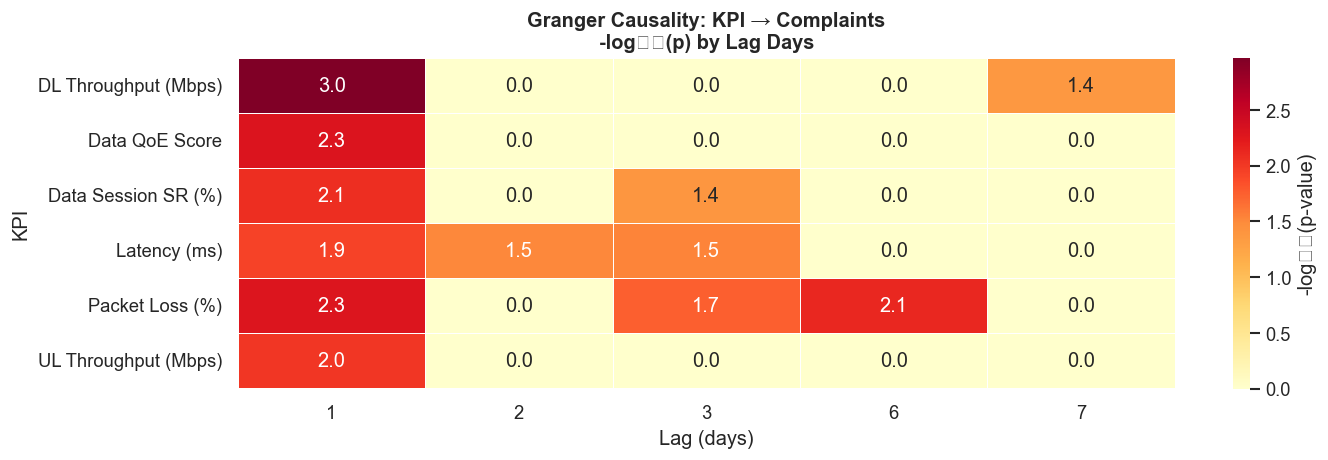

In [36]:
if not granger.empty and granger["is_significant"].any():
    sig = granger[granger["is_significant"]].copy()
    sig["neg_log_p"] = -np.log10(sig["min_p_value"].clip(lower=1e-10))

    pivot = (
        sig.groupby(["kpi_label", "best_lag_days"])["neg_log_p"]
        .mean()
        .unstack(fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(12, max(4, len(pivot) * 0.55)))
    sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".1f",
                linewidths=0.3, ax=ax,
                cbar_kws={"label": "-log₁₀(p-value)"})
    ax.set_title("Granger Causality: KPI → Complaints\n-log₁₀(p) by Lag Days",
                 fontweight="bold")
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("KPI")
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d3_granger_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No significant Granger results to plot.")
    print("With real operator data, this section will show causal lead times (1–3 days typical).")

## Cell 12 — QoE degradation event table

In [37]:
print("=== QoE Degradation → Complaint Impact ===")
if qoe_events.empty:
    print("No QoE event results — check that qoe_score_mean exists in kpi_agg.")
else:
    display(  # type: ignore[name-defined]
        qoe_events[[
            "region", "n_degraded_days", "n_normal_days",
            "mean_complaints_degraded", "mean_complaints_normal",
            "pct_increase", "p_value", "is_significant",
        ]]
    )

=== QoE Degradation → Complaint Impact ===


,region,n_degraded_days,n_normal_days,mean_complaints_degraded,mean_complaints_normal,pct_increase,p_value,is_significant
0,Tunis Gouvernorat,8,329,7.38,8.51,-13.3,0.99237,False
1,Ben Arous Gouvernorat,15,322,4.13,6.03,-31.5,1.00000,False
2,Gafsa Gouvernorat,52,285,1.83,3.49,-47.6,1.00000,False
3,Bizerte Gouvernorat,32,305,1.59,3.62,-56.0,1.00000,False
4,Nabeul Gouvernorat,21,316,2.14,4.98,-57.0,1.00000,False
5,Mednine Gouvernorat,33,304,1.55,3.74,-58.7,1.00000,False
6,Manouba Gouvernorat,41,296,1.17,3.00,-61.0,1.00000,False
7,Jendouba Gouvernorat,85,252,0.71,2.44,-71.1,1.00000,False
8,Monastir Gouvernorat,47,290,0.79,3.07,-74.3,1.00000,False
9,Sidi Bouzid Gouvernorat,49,288,0.59,2.77,-78.7,1.00000,False


## Cell 13 — QoE degradation impact charts

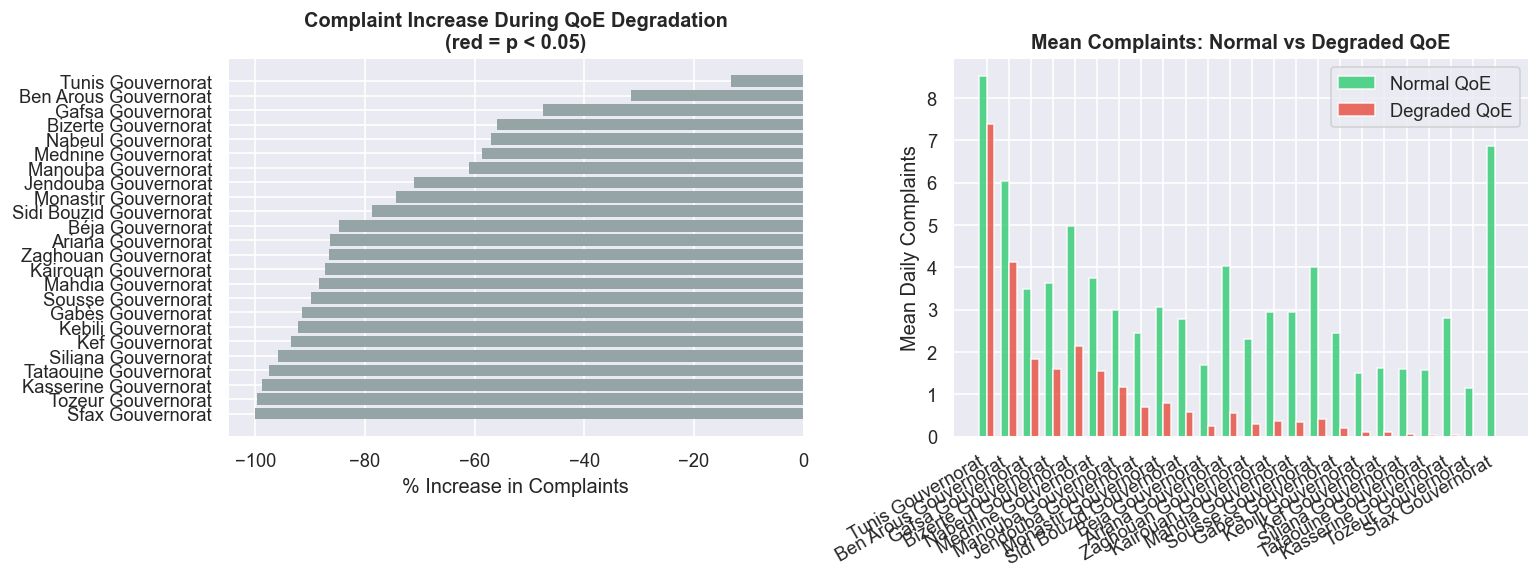

In [38]:
if not qoe_events.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    qoe_sorted  = qoe_events.sort_values("pct_increase", ascending=True)
    colors_bar  = ["#e74c3c" if s else "#95a5a6" for s in qoe_sorted["is_significant"]]

    axes[0].barh(qoe_sorted["region"], qoe_sorted["pct_increase"],
                 color=colors_bar, edgecolor="none")
    axes[0].axvline(0, color="white", linewidth=0.8)
    axes[0].set_title("Complaint Increase During QoE Degradation\n(red = p < 0.05)",
                      fontweight="bold")
    axes[0].set_xlabel("% Increase in Complaints")

    x     = np.arange(len(qoe_events))
    width = 0.35
    axes[1].bar(x - width / 2, qoe_events["mean_complaints_normal"],
                width, label="Normal QoE", color="#2ecc71", alpha=0.8)
    axes[1].bar(x + width / 2, qoe_events["mean_complaints_degraded"],
                width, label="Degraded QoE", color="#e74c3c", alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(qoe_events["region"], rotation=30, ha="right")
    axes[1].set_ylabel("Mean Daily Complaints")
    axes[1].set_title("Mean Complaints: Normal vs Degraded QoE", fontweight="bold")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d3_qoe_degradation_impact.png", dpi=150, bbox_inches="tight")
    plt.show()

## Cell 14 — QoE vs complaint timeline
FIX N4: use the actual top hotspot region instead of hardcoding "Tunis".

Timeline region: Ariana Gouvernorat


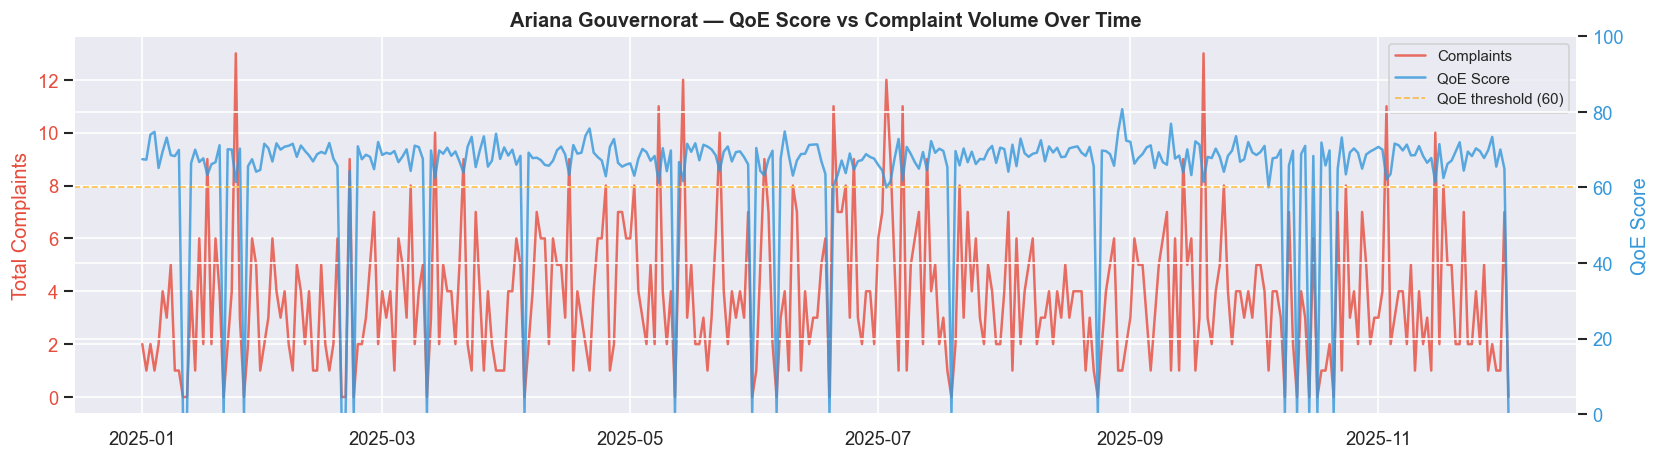

In [39]:
_top_region = summary.get("top_hotspot_region") or complaint_agg["region"].value_counts().index[0]
print(f"Timeline region: {_top_region}")

ca_r = complaint_agg[complaint_agg["region"] == _top_region].sort_values("date")
ka_r = kpi_agg[kpi_agg["region"] == _top_region].sort_values("date").copy()

# Derive composite QoE if needed
if "qoe_score_mean" not in ka_r.columns:
    has_d = "data_qoe_score_mean"  in ka_r.columns
    has_v = "voice_qoe_score_mean" in ka_r.columns
    if has_d and has_v:
        ka_r["qoe_score_mean"] = (
            0.55 * ka_r["data_qoe_score_mean"] + 0.45 * ka_r["voice_qoe_score_mean"]
        )
    elif has_d:
        ka_r["qoe_score_mean"] = ka_r["data_qoe_score_mean"]

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(pd.to_datetime(ca_r["date"]), ca_r["total_complaints"],
         color="#e74c3c", linewidth=1.5, alpha=0.8, label="Complaints")
ax1.set_ylabel("Total Complaints", color="#e74c3c")
ax1.tick_params(axis="y", labelcolor="#e74c3c")

if "qoe_score_mean" in ka_r.columns:
    ax2.plot(pd.to_datetime(ka_r["date"]), ka_r["qoe_score_mean"],
             color="#3498db", linewidth=1.5, alpha=0.8, label="QoE Score")
    ax2.axhline(60, color="orange", linestyle="--", linewidth=1,
                alpha=0.7, label="QoE threshold (60)")
    ax2.set_ylabel("QoE Score", color="#3498db")
    ax2.tick_params(axis="y", labelcolor="#3498db")
    ax2.set_ylim(0, 100)
else:
    ax2.set_visible(False)
    print(f"  qoe_score_mean not available for {_top_region} — QoE line omitted")

ax1.set_title(f"{_top_region} — QoE Score vs Complaint Volume Over Time",
              fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES}/d3_qoe_vs_complaints_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 15 — CCF table

In [40]:
print("=== Cross-Correlation: KPI → Complaints (Peak Lag) ===")
if ccf.empty:
    print("No CCF results — no KPI mean columns in kpi_agg.")
else:
    display(  # type: ignore[name-defined]
        ccf[["region", "kpi_label", "best_lag_days",
             "peak_correlation", "direction"]].head(15)
    )

=== Cross-Correlation: KPI → Complaints (Peak Lag) ===


,region,kpi_label,best_lag_days,peak_correlation,direction
0,Tozeur Gouvernorat,Call Drop Rate (%),0,0.9200,direct
1,Tozeur Gouvernorat,Packet Loss (%),0,0.9072,direct
2,Tozeur Gouvernorat,Latency (ms),0,0.9072,direct
3,Tozeur Gouvernorat,Handover SR (%),0,0.9061,direct
4,Tozeur Gouvernorat,Voice MOS,0,0.9057,direct
5,Tozeur Gouvernorat,Call Setup SR (%),0,0.9055,direct
6,Tozeur Gouvernorat,Data Session SR (%),0,0.9045,direct
7,Tozeur Gouvernorat,Voice QoE Score,0,0.9032,direct
8,Tozeur Gouvernorat,Data QoE Score,0,0.9022,direct
9,Tozeur Gouvernorat,UL Throughput (Mbps),0,0.8531,direct


## Cell 16 — Average peak lag & correlation per KPI

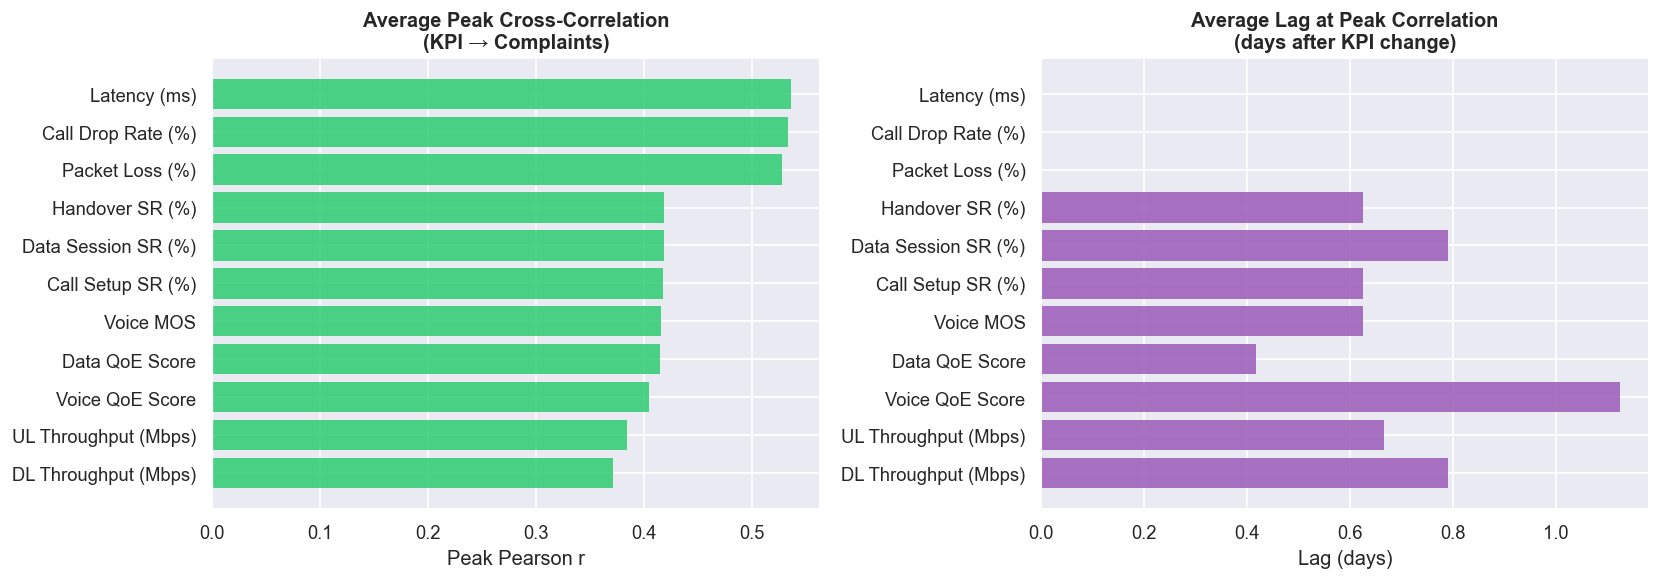

In [41]:
if not ccf.empty:
    avg_lag = (
        ccf.groupby("kpi_label")
        .agg(avg_lag=("best_lag_days", "mean"),
             avg_corr=("peak_correlation", "mean"))
        .reset_index()
        .sort_values("avg_corr")
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors_ccf = ["#e74c3c" if r < 0 else "#2ecc71" for r in avg_lag["avg_corr"]]
    axes[0].barh(avg_lag["kpi_label"], avg_lag["avg_corr"],
                 color=colors_ccf, edgecolor="none", alpha=0.85)
    axes[0].axvline(0, color="white", linewidth=0.8, linestyle="--")
    axes[0].set_title("Average Peak Cross-Correlation\n(KPI → Complaints)", fontweight="bold")
    axes[0].set_xlabel("Peak Pearson r")

    axes[1].barh(avg_lag["kpi_label"], avg_lag["avg_lag"],
                 color="#9b59b6", edgecolor="none", alpha=0.85)
    axes[1].set_title("Average Lag at Peak Correlation\n(days after KPI change)",
                      fontweight="bold")
    axes[1].set_xlabel("Lag (days)")

    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d3_ccf_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No CCF data to plot.")

## Cell 17 — CCF lag profile for one region (top 3 KPIs)
FIX N2: pearsonr already imported at Cell 0 — no local re-import.
FIX N3: guard for empty ccf or missing region.

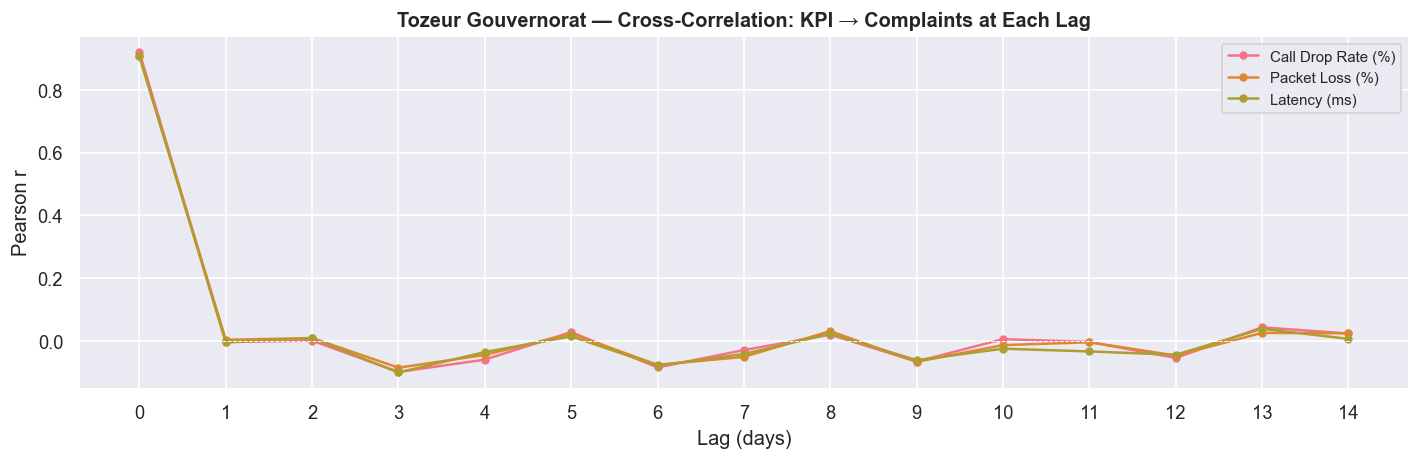

In [42]:
if ccf.empty:
    print("CCF results empty — lag profile skipped.")
else:
    _ccf_region = summary.get("top_hotspot_region") or ccf["region"].iloc[0]
    max_lag     = 14

    ca_r       = complaint_agg[complaint_agg["region"] == _ccf_region].sort_values("date")
    ka_r       = kpi_agg[kpi_agg["region"] == _ccf_region].sort_values("date")
    merged_ccf = (
        ca_r[["date", "total_complaints"]]
        .merge(ka_r, on="date", how="inner")
        .dropna()
        .reset_index(drop=True)
    )

    # FIX N3: guard on ccf subset before sort
    ccf_region_sub = ccf[ccf["region"] == _ccf_region]
    if ccf_region_sub.empty:
        print(f"  No CCF results for region '{_ccf_region}' — lag profile skipped.")
    else:
        top_kpi_for_ccf = (
            ccf_region_sub
            .sort_values("abs_correlation", ascending=False)
            .head(3)
        )

        fig, ax = plt.subplots(figsize=(12, 4))
        for i, (_, row) in enumerate(top_kpi_for_ccf.iterrows()):
            kpi_col = row["kpi"]
            kpi_lbl = row["kpi_label"]
            if kpi_col not in merged_ccf.columns:
                continue
            lags   = range(0, max_lag + 1)
            r_vals = []
            for lag in lags:
                x = merged_ccf[kpi_col].values if lag == 0 else merged_ccf[kpi_col].values[:-lag]
                y = merged_ccf["total_complaints"].values if lag == 0 else merged_ccf["total_complaints"].values[lag:]
                r, _ = pearsonr(x, y) if len(x) > 5 else (0, 1)   # FIX N2: uses module-level import
                r_vals.append(r)
            ax.plot(list(lags), r_vals, marker="o", markersize=4,
                    linewidth=1.5, label=kpi_lbl, color=COLORS[i])

        ax.axhline(0, color="white", linewidth=0.6, linestyle="--")
        ax.set_title(f"{_ccf_region} — Cross-Correlation: KPI → Complaints at Each Lag",
                     fontweight="bold")
        ax.set_xlabel("Lag (days)")
        ax.set_ylabel("Pearson r")
        ax.legend(fontsize=9)
        ax.set_xticks(range(0, max_lag + 1))
        plt.tight_layout()
        plt.savefig(f"{FIGURES}/d3_ccf_lag_profile.png", dpi=150, bbox_inches="tight")
        plt.show()

## Cell 18 — D3 Summary

In [43]:
print("=" * 60)
print("  D3 — CORRELATION STUDY: KEY FINDINGS")
print("=" * 60)

if "top_correlated_kpis" in summary:
    print("\n  Most correlated KPIs with complaint volume:")
    for kpi, r in zip(summary["top_correlated_kpis"], summary["top_pearson_r"]):
        print(f"    {kpi:<40} r = {r:+.3f}")

if "most_predictive_threshold" in summary:
    t = summary["most_predictive_threshold"]
    print(f"\n  Best KPI threshold for spike detection:")
    print(f"    {t['kpi']} {t['direction']} {t['threshold']}")

if "granger_significant_pairs" in summary:
    print(f"\n  Granger causality: {summary['granger_significant_pairs']} significant pairs")
    if "strongest_granger_cause" in summary:
        g = summary["strongest_granger_cause"]
        print(f"    Strongest: {g['kpi']} (lag={g['lag']}d, p={g['p_value']:.4f})")

if "qoe_degradation_impact" in summary:
    q = summary["qoe_degradation_impact"]
    print(f"\n  QoE degradation impact:")
    print(f"    Significant regions : {q['significant_regions']}")
    print(f"    Max complaint spike : +{q['max_pct_increase']:.1f}%")
    print(f"    Avg complaint spike : +{q['avg_pct_increase']:.1f}%")

print()
print("  Report tables saved to reports/exports/  ✓")
print("  Figures saved to reports/figures/        ✓")

print()
print("  D3 output files:")
for f in sorted(Path("reports/exports").glob("d3_*.csv")):
    print(f"    {f}")

  D3 — CORRELATION STUDY: KEY FINDINGS

  Most correlated KPIs with complaint volume:
    Call Drop Rate (%)                       r = +0.457
    Latency (ms)                             r = +0.457
    Packet Loss (%)                          r = +0.449

  Best KPI threshold for spike detection:
    Call Setup SR (%) below 85.863

  Granger causality: 21 significant pairs
    Strongest: Data Session SR (%) (lag=1d, p=0.0003)

  QoE degradation impact:
    Significant regions : 0
    Max complaint spike : +-13.3%
    Avg complaint spike : +-76.7%

  Report tables saved to reports/exports/  ✓
  Figures saved to reports/figures/        ✓

  D3 output files:
    reports\exports\d3_correlation_rankings.csv
    reports\exports\d3_cross_correlation.csv
    reports\exports\d3_granger_causality.csv
    reports\exports\d3_kpi_thresholds.csv
    reports\exports\d3_qoe_event_analysis.csv


## Cell 19 — D3 Deliverable Checklist
FIX N8: consistent pass/fail checklist matching Notebooks 01–03.

In [45]:
print("=" * 60)
print("  DELIVERABLE D3 — CHECKLIST")
print("=" * 60)

def _file_exists(pattern: str) -> bool:
    return any(Path(FIGURES).glob(pattern))

checklist = [
    ("KPI correlations computed",
     not top_corr.empty),
    ("Pearson r bar chart saved",
     _file_exists("d3_pearson_correlation_bar.png")),
    ("Full correlation heatmap saved",
     _file_exists("d3_full_correlation_heatmap.png")),
    ("KPI thresholds detected",
     not thresholds.empty),
    ("Threshold chart saved",
     _file_exists("d3_kpi_thresholds.png")),
    ("Granger causality tested",
     not granger.empty),
    ("QoE degradation events analysed",
     not qoe_events.empty),
    ("QoE impact chart saved",
     _file_exists("d3_qoe_degradation_impact.png")),
    ("QoE vs complaints timeline saved",
     _file_exists("d3_qoe_vs_complaints_timeline.png")),
    ("CCF computed",
     not ccf.empty),
    ("CCF summary chart saved",
     _file_exists("d3_ccf_summary.png")),
    ("CCF lag profile saved",
     _file_exists("d3_ccf_lag_profile.png")),
    ("D3 CSV exports written",
     any(Path("reports/exports").glob("d3_*.csv"))),
]

all_pass = True
for description, condition in checklist:
    status = "✓" if condition else "✗"
    if not condition:
        all_pass = False
    print(f"  [{status}] {description}")

print("=" * 60)
if all_pass:
    print("  D3 COMPLETE — all checks passed ✓")
    print("  → Next: Notebook 05 — Machine Learning Models")
else:
    print("  D3 INCOMPLETE — review failed checks above ✗")
print("=" * 60)

  DELIVERABLE D3 — CHECKLIST
  [✓] KPI correlations computed
  [✓] Pearson r bar chart saved
  [✓] Full correlation heatmap saved
  [✓] KPI thresholds detected
  [✓] Threshold chart saved
  [✓] Granger causality tested
  [✓] QoE degradation events analysed
  [✓] QoE impact chart saved
  [✓] QoE vs complaints timeline saved
  [✓] CCF computed
  [✓] CCF summary chart saved
  [✓] CCF lag profile saved
  [✓] D3 CSV exports written
  D3 COMPLETE — all checks passed ✓
  → Next: Notebook 05 — Machine Learning Models
